In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

# Attempt to import statsmodels for the professional LOESS trendline
try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    warnings.warn("statsmodels not found. LOESS trend line will fall back to a rolling average. Run 'pip install statsmodels' for best results.")

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [5]:
# ==========================================
# ---> 1. MASTER PLOT CONFIGURATION <---
# ==========================================
X_PARAM        = 'delta_P'  # Options: 'delta_t', 'delta_P', 'N_d', 'delta_n', 'Ratio', 'delta_P_delta_t'
COLOR_PARAM    = 'delta_n'          # Options: 'delta_t', 'delta_P', 'N_d', 'delta_n', 'Ratio', 'delta_P_delta_t'
NORMALIZE_COST = False              # True: Normalized Penalty (%), False: Raw Dollars ($)

# --- Color Grouping ---
USE_QUANTILES   = False      # Set to True to group COLOR_PARAM into mathematical bins
LOCAL_QUANTILES = False      # True: Quantiles calculated relative to the X-axis neighborhood
LOCAL_WINDOW    = 10         # Number of neighboring points to calculate local rank
N_QUANTILES     = 10         # Number of bins (if USE_QUANTILES is True)

# --- Harmonic Marker Identification (List Logic) ---
MARK_HARMONICS        = True      # True: Use different markers for harmonic vs inharmonic grids
HARMONIC_EXACT_VALUES = [80,160,240,320, 400, 480, 540]           # e.g., [150, 200]
HARMONIC_MULTIPLES_OF = []           # e.g., [50] flags 50, 100, 150...
HARMONIC_DIVISORS_OF  = []           # e.g., [200] flags 200, 100, 50, 40...

# --- Statistical Analysis Lines ---
PLOT_PARETO          = False # The absolute lowest boundary (Rolling Minimum)
PLOT_TREND           = True  # The center of mass (LOESS or Rolling Average)
TREND_PER_GROUP      = False # True: One trend per color group. False: One global trend
PLOT_QUANTILE_BANDS  = True  # The 10th and 90th percentile bands

LOESS_FRAC           = 0.25   # Fraction of data used for LOESS smoothing
SMOOTHING_WIN        = 5   # Absolute window size for rolling fallbacks

# --- Rigorous Calculus Proof ---
PLOT_DERIVATIVE      = False  # Superimpose the derivative gradient
DERIVATIVE_TARGET    = 'q90' # Options: 'trend', 'q10', 'q90'
# ==========================================

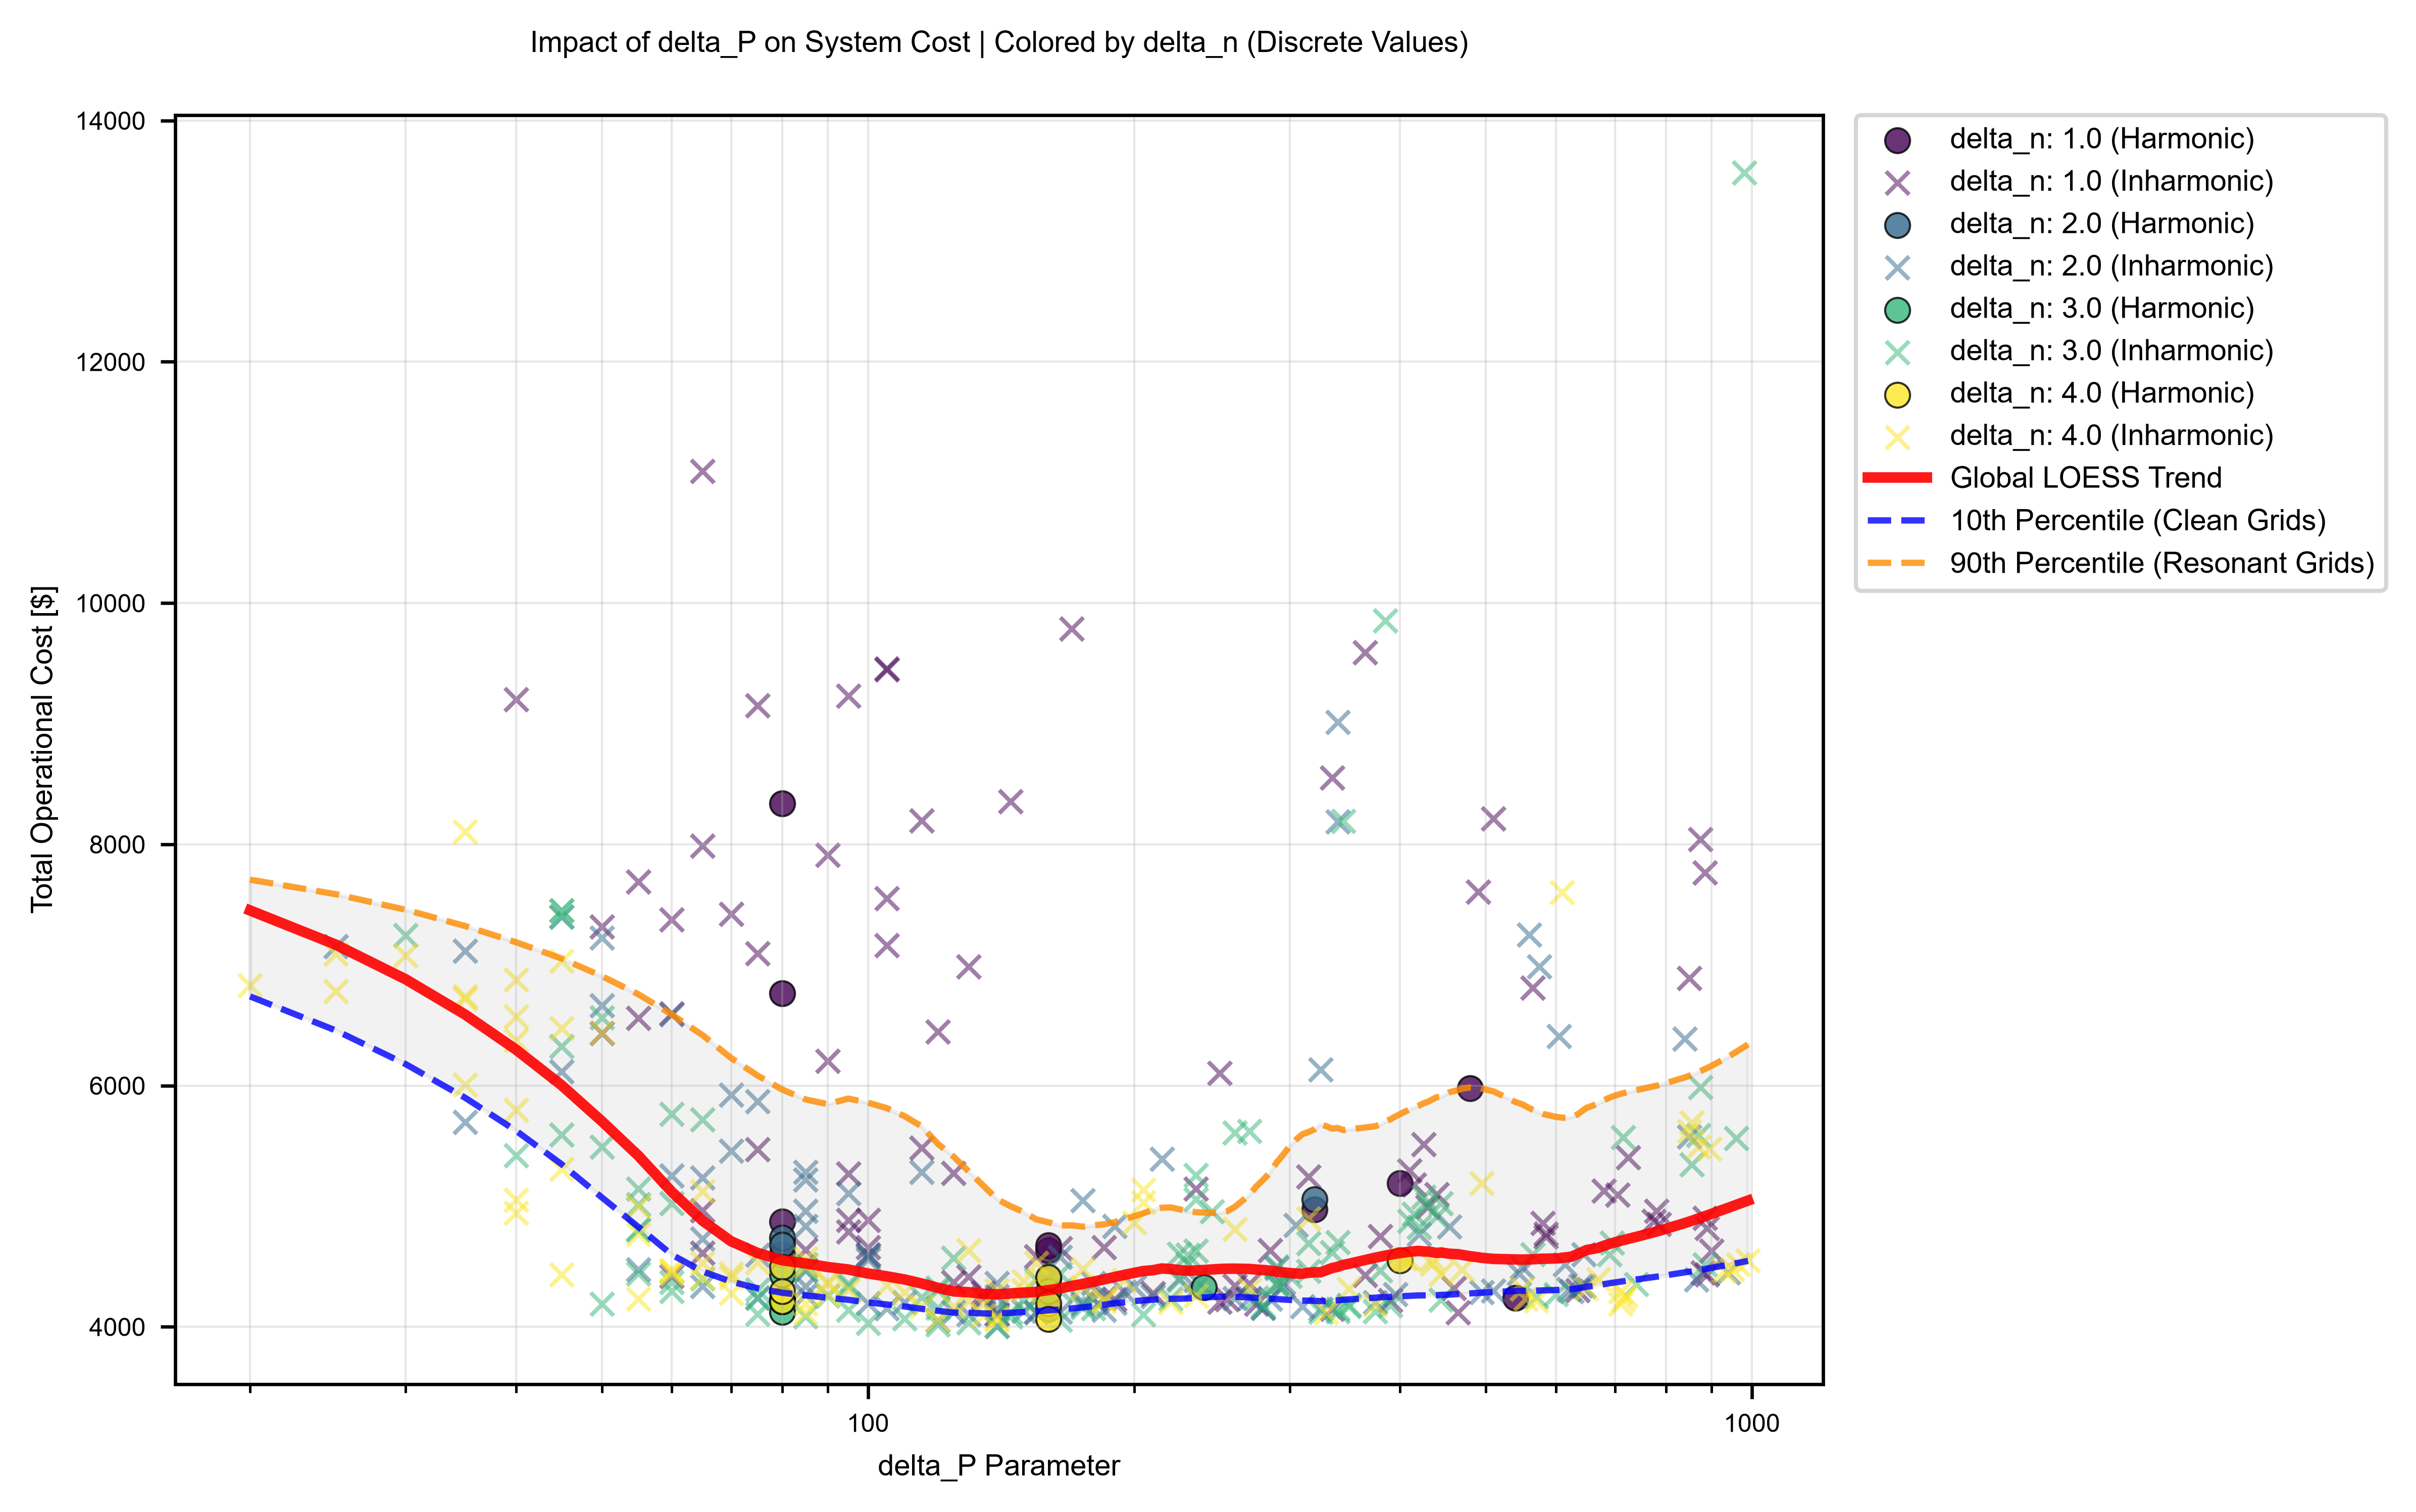

In [6]:
# Load data and construct calculated product parameter
df_plot = pd.read_csv("cost_vs_dt_scatter.csv")
df_plot['delta_P_delta_t'] = df_plot['delta_P'] * df_plot['delta_t']

os.makedirs('figures', exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 5))

# 1. Setup the Y-Axis
if NORMALIZE_COST:
    min_cost = df_plot['Total Cost [$]'].min()
    df_plot['Y_Value'] = ((df_plot['Total Cost [$]'] - min_cost) / min_cost) * 100
    y_label = 'Normalized Cost Penalty (%)'
else:
    df_plot['Y_Value'] = df_plot['Total Cost [$]']
    y_label = 'Total Operational Cost [$]'

# 2. Harmonic Tagging
if MARK_HARMONICS:
    is_harmonic = pd.Series(False, index=df_plot.index)
    if HARMONIC_EXACT_VALUES:
        is_harmonic |= df_plot['delta_P'].isin(HARMONIC_EXACT_VALUES)
    if HARMONIC_MULTIPLES_OF:
        for val in HARMONIC_MULTIPLES_OF:
            is_harmonic |= (df_plot['delta_P'] % val == 0)
    if HARMONIC_DIVISORS_OF:
        for val in HARMONIC_DIVISORS_OF:
            is_harmonic |= (val % df_plot['delta_P'] == 0)
    df_plot['Is_Harmonic'] = is_harmonic
else:
    df_plot['Is_Harmonic'] = True

# 3. Handle the Color Grouping
if USE_QUANTILES:
    if LOCAL_QUANTILES:
        df_plot = df_plot.sort_values(X_PARAM).reset_index(drop=True)
        def local_percentile(arr):
            target = arr[len(arr)//2]
            return (arr <= target).mean()
        df_plot['Local_Pct'] = df_plot[COLOR_PARAM].rolling(
            window=LOCAL_WINDOW, center=True, min_periods=1
        ).apply(local_percentile, raw=True)
        bin_edges = np.linspace(0, 1, N_QUANTILES + 1)
        bin_labels = [f"Bottom {int(100/N_QUANTILES)}%" if i==0 else 
                      f"Top {int(100/N_QUANTILES)}%" if i==N_QUANTILES-1 else 
                      f"Q{i+1} (Local)" for i in range(N_QUANTILES)]
        df_plot['Color_Bin'] = pd.cut(df_plot['Local_Pct'], bins=bin_edges, labels=bin_labels, include_lowest=True)
        df_plot['Legend_Label'] = df_plot['Color_Bin'].astype(str)
        group_col = 'Color_Bin'
    elif df_plot[COLOR_PARAM].nunique() > N_QUANTILES:
        df_plot['Color_Bin'] = pd.qcut(df_plot[COLOR_PARAM], q=N_QUANTILES, duplicates='drop')
        def format_interval(interv):
            if isinstance(interv, pd.Interval):
                return f"{interv.left:.1f} to {interv.right:.1f}"
            return str(interv)
        df_plot['Legend_Label'] = df_plot['Color_Bin'].apply(format_interval)
        group_col = 'Color_Bin'
else:
    df_plot['Legend_Label'] = df_plot[COLOR_PARAM].apply(lambda x: f"{x:.1f}" if isinstance(x, float) else str(x))
    group_col = COLOR_PARAM

try:
    unique_groups = sorted(df_plot[group_col].unique())
except TypeError:
    unique_groups = sorted(df_plot[group_col].unique(), key=lambda x: str(x))

cmap = plt.get_cmap('viridis')
colors = {grp: cmap(i / max(1, len(unique_groups)-1)) for i, grp in enumerate(unique_groups)}

# 4. Plot the Scatter Cloud
for grp in unique_groups:
    subset_grp = df_plot[df_plot[group_col] == grp]
    label_str = subset_grp['Legend_Label'].iloc[0]
    sub_harmonic = subset_grp[subset_grp['Is_Harmonic'] == True]
    if not sub_harmonic.empty:
        ax.scatter(sub_harmonic[X_PARAM], sub_harmonic['Y_Value'], 
                   marker='o', s=35, color=colors[grp], alpha=0.8, edgecolors='k', linewidth=0.5,
                   label=f"{COLOR_PARAM}: {label_str} (Harmonic)" if MARK_HARMONICS else f"{COLOR_PARAM}: {label_str}")
    if MARK_HARMONICS:
        sub_ugly = subset_grp[subset_grp['Is_Harmonic'] == False]
        if not sub_ugly.empty:
            ax.scatter(sub_ugly[X_PARAM], sub_ugly['Y_Value'], 
                       marker='x', s=30, color=colors[grp], alpha=0.5, linewidth=1.0,
                       label=f"{COLOR_PARAM}: {label_str} (Inharmonic)")

# --- Dictionary to store curve arrays for derivative calculation ---
curves_data = {}
df_sorted = df_plot.sort_values(X_PARAM).copy()

# 5. Statistical Analysis Lines
if PLOT_PARETO:
    discrete_min = df_sorted.groupby(X_PARAM)['Y_Value'].min()
    smoothed_pareto = discrete_min.rolling(window=SMOOTHING_WIN, center=True, min_periods=1).mean()
    ax.plot(smoothed_pareto.index, smoothed_pareto.values, color='black', linestyle=':', linewidth=1.5, label='Pareto Front (Lower Bound)')

if PLOT_TREND:
    if TREND_PER_GROUP:
        for grp in unique_groups:
            subset = df_plot[df_plot[group_col] == grp].sort_values(X_PARAM)
            if len(subset) < 3: continue 
            if HAS_STATSMODELS:
                lowess = sm.nonparametric.lowess(subset['Y_Value'], subset[X_PARAM], frac=LOESS_FRAC)
                ax.plot(lowess[:, 0], lowess[:, 1], color=colors[grp], linestyle='-', linewidth=2.5, alpha=0.9)
            else:
                smoothed_trend = subset['Y_Value'].rolling(window=SMOOTHING_WIN, center=True, min_periods=1).median()
                ax.plot(subset[X_PARAM], smoothed_trend, color=colors[grp], linestyle='-', linewidth=2.5, alpha=0.9)
    else:
        if HAS_STATSMODELS:
            lowess = sm.nonparametric.lowess(df_sorted['Y_Value'], df_sorted[X_PARAM], frac=LOESS_FRAC)
            x_val, y_val = lowess[:, 0], lowess[:, 1]
            ax.plot(x_val, y_val, color='red', linestyle='-', linewidth=2.5, alpha=0.9, label='Global LOESS Trend')
            curves_data['trend'] = (x_val, y_val)
        else:
            smoothed_trend = df_sorted['Y_Value'].rolling(window=SMOOTHING_WIN, center=True, min_periods=1).median()
            ax.plot(df_sorted[X_PARAM], smoothed_trend, color='red', linestyle='-', linewidth=2.5, alpha=0.9, label='Global Rolling Median')
            curves_data['trend'] = (df_sorted[X_PARAM].values, smoothed_trend.values)

if PLOT_QUANTILE_BANDS:
    q10_raw = df_sorted['Y_Value'].rolling(window=SMOOTHING_WIN, center=True, min_periods=1).quantile(0.10)
    q90_raw = df_sorted['Y_Value'].rolling(window=SMOOTHING_WIN, center=True, min_periods=1).quantile(0.90)
    
    if HAS_STATSMODELS:
        q10_smooth = sm.nonparametric.lowess(q10_raw, df_sorted[X_PARAM], frac=LOESS_FRAC)[:, 1]
        q90_smooth = sm.nonparametric.lowess(q90_raw, df_sorted[X_PARAM], frac=LOESS_FRAC)[:, 1]
    else:
        q10_smooth = q10_raw.rolling(window=SMOOTHING_WIN, center=True, min_periods=1).mean().values
        q90_smooth = q90_raw.rolling(window=SMOOTHING_WIN, center=True, min_periods=1).mean().values

    ax.plot(df_sorted[X_PARAM], q10_smooth, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, label='10th Percentile (Clean Grids)')
    ax.plot(df_sorted[X_PARAM], q90_smooth, color='darkorange', linestyle='--', linewidth=1.5, alpha=0.8, label='90th Percentile (Resonant Grids)')
    ax.fill_between(df_sorted[X_PARAM], q10_smooth, q90_smooth, color='grey', alpha=0.1)
    
    curves_data['q10'] = (df_sorted[X_PARAM].values, q10_smooth)
    curves_data['q90'] = (df_sorted[X_PARAM].values, q90_smooth)

# 6. Derivative Plotting & Root Finding (Calculus Proof)
ax2 = None
if PLOT_DERIVATIVE and DERIVATIVE_TARGET in curves_data:
    ax2 = ax.twinx()
    x_raw, y_raw = curves_data[DERIVATIVE_TARGET]
    
    # Clean the arrays: np.gradient requires strictly unique X values to avoid division by zero
    df_deriv = pd.DataFrame({'x': x_raw, 'y': y_raw}).dropna().drop_duplicates('x').sort_values('x')
    x_clean = df_deriv['x'].values
    y_clean = df_deriv['y'].values
    
    # Calculate First Derivative (dy/dx)
    dy = np.gradient(y_clean, x_clean)
    
    ax2.plot(x_clean, dy, color='magenta', linestyle='-.', linewidth=1.5, alpha=0.8, label=f'Gradient ($d$/$d${X_PARAM} of {DERIVATIVE_TARGET})')
    ax2.axhline(0, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.set_ylabel(f'Gradient Magnitude', color='darkmagenta')
    ax2.tick_params(axis='y', labelcolor='darkmagenta')

    # --- EXACT ROOT FINDING ALGORITHM ---
    print("\n" + "="*40)
    print(f" MATHEMATICAL ROOTS FOR {DERIVATIVE_TARGET.upper()} TRENDLINE")
    print("="*40)
    
    # Find indices where the derivative changes sign
    zero_crossings = np.where(np.diff(np.sign(dy)))[0]
    
    if len(zero_crossings) == 0:
        print("No zero-crossings detected.")
    else:
        for idx in zero_crossings:
            x0, x1 = x_clean[idx], x_clean[idx+1]
            y0, y1 = dy[idx], dy[idx+1]
            
            # Linear interpolation for sub-grid accuracy
            exact_root = x0 - y0 * (x1 - x0) / (y1 - y0)
            
            # If the derivative goes from negative to positive, it's a minimum (a well)
            if y0 < 0:
                print(f"📉 MINIMUM (Well) found at {X_PARAM} = {exact_root:,.1f}")
            else:
                print(f"📈 MAXIMUM (Peak) found at {X_PARAM} = {exact_root:,.1f}")
    print("="*40 + "\n")

# 7. Formatting & Scaling
ax.set_xlabel(f"{X_PARAM} Parameter")
ax.set_ylabel(y_label)

title_context = "(Local Quantiles)" if USE_QUANTILES and LOCAL_QUANTILES else "(Global Quantiles)" if USE_QUANTILES else "(Discrete Values)"
ax.set_title(f"Impact of {X_PARAM} on System Cost | Colored by {COLOR_PARAM} {title_context}", pad=15)

if X_PARAM in ['delta_t', 'Ratio', 'delta_P_delta_t', "delta_P"]:
    ax.set_xscale('log')
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

if NORMALIZE_COST:
    ax.set_ylim(bottom=-2)
    
ax.grid(True, which='both', ls='-', alpha=0.3)

# Handle Legends for both axes
handles, labels = ax.get_legend_handles_labels()
if ax2:
    h2, l2 = ax2.get_legend_handles_labels()
    handles.extend(h2)
    labels.extend(l2)
    
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), 
          bbox_to_anchor=(1.10, 1) if ax2 else (1.02, 1), loc='upper left', fontsize=7, borderaxespad=0.)

plt.tight_layout()
filename_save = f"figures/06_advanced_scatter_{X_PARAM}.png"
plt.savefig(filename_save, dpi=300, bbox_inches='tight')
plt.show()

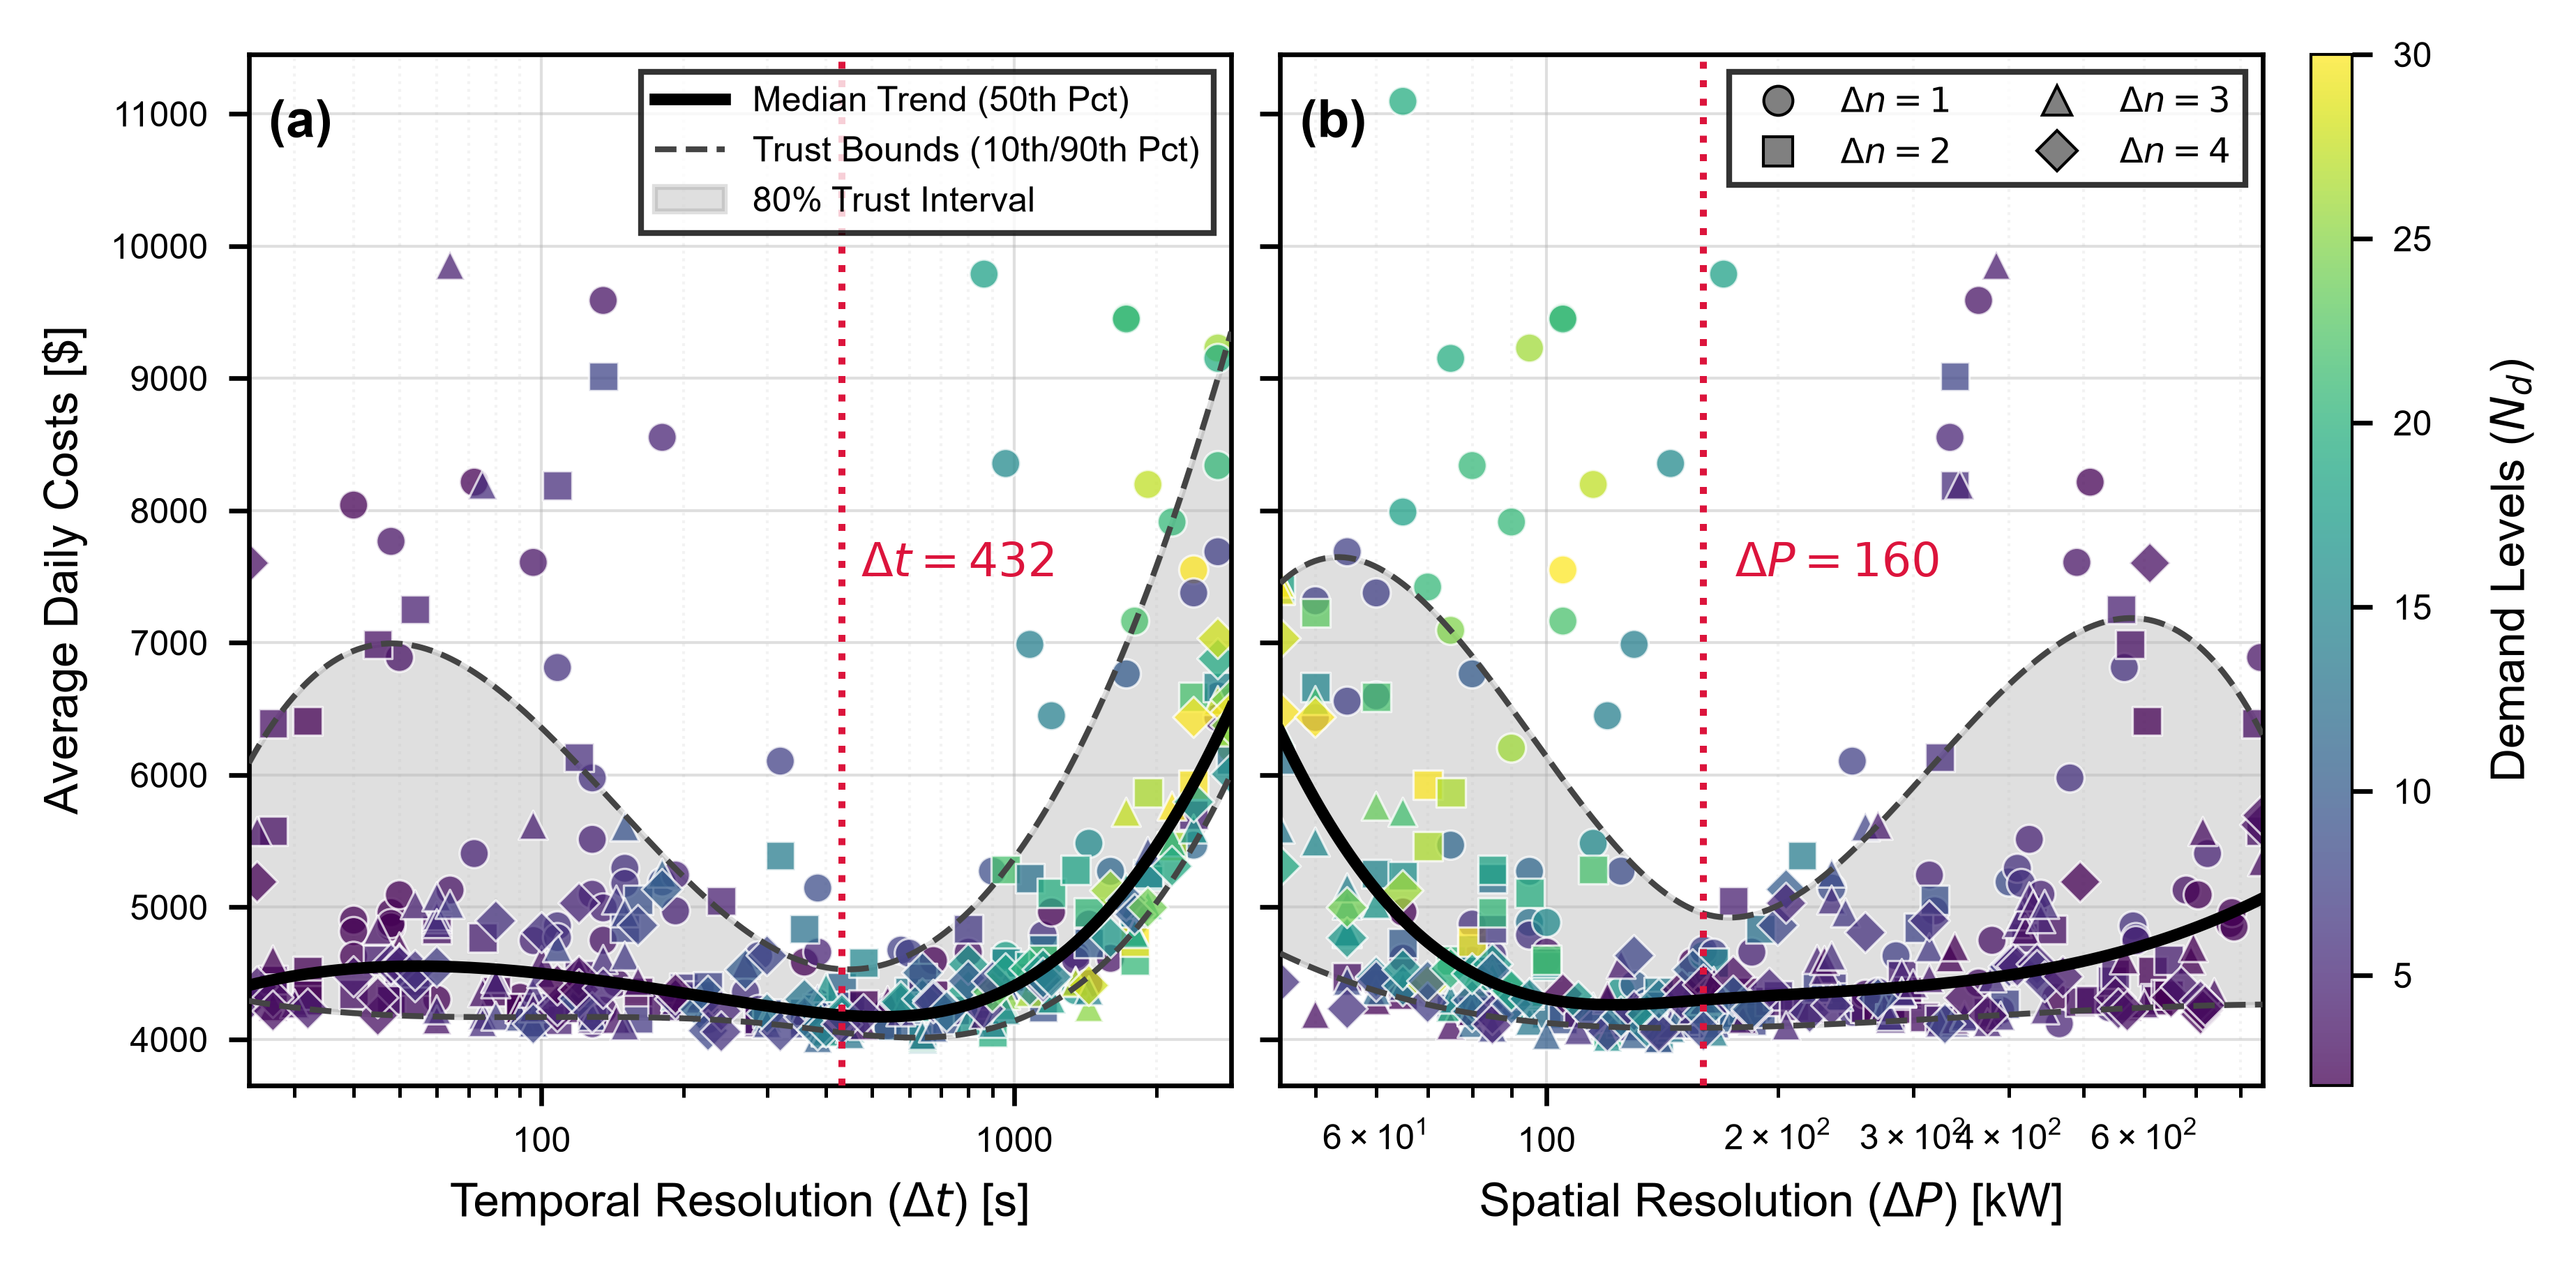

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf
import warnings

# ==========================================
# 1. PUBLICATION-READY PLOT CONFIGURATION
# ==========================================
plt.rcParams.update({
    'figure.dpi': 600,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 8,
    'lines.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4
})

LOG_X_AXIS = True
TRUNCATE_TAILS = 0.05  # Pre-filter extreme sparse tails

# Target optimal physical coordinates
REF_VALS = {'delta_t': 432.0, 'delta_P': 160.0}

# Load Data
df_plot = pd.read_csv("cost_vs_dt_scatter.csv")
marker_map = {1.0: 'o', 2.0: 's', 3.0: '^', 4.0: 'D'}

# 7.48 inches = 190mm (Standard Double-Column width for Elsevier)
fig, axes = plt.subplots(1, 2, figsize=(7.48, 3.2), sharey=True)
x_params = ['delta_t', 'delta_P']
x_labels = ['Temporal Resolution ($\\Delta t$) [s]', 'Spatial Resolution ($\\Delta P$) [kW]']

line_legend_handles = []
scatter_legend_handles = []

for i, ax in enumerate(axes):
    X_PARAM = x_params[i]
    
    # ----------------------------------------------------
    # 2. PRE-FILTER THE DATA (Clip edges for spline support)
    # ----------------------------------------------------
    x_min_safe = df_plot[X_PARAM].quantile(TRUNCATE_TAILS)
    x_max_safe = df_plot[X_PARAM].quantile(1 - TRUNCATE_TAILS)
    
    mask = (df_plot[X_PARAM] >= x_min_safe) & (df_plot[X_PARAM] <= x_max_safe)
    df_sorted = df_plot[mask].sort_values(X_PARAM).dropna(subset=[X_PARAM, 'Total Cost [$]'])
    
    # ----------------------------------------------------
    # 3. SCATTER PLOT 
    # ----------------------------------------------------
    for dn_val, m in marker_map.items():
        subset = df_sorted[df_sorted['delta_n'] == dn_val]
        if not subset.empty:
            sc = ax.scatter(
                subset[X_PARAM], 
                subset['Total Cost [$]'], 
                c=subset['N_d'], 
                cmap='viridis', 
                marker=m, 
                s=25, 
                alpha=0.75,              # Transparency to reveal overlap
                edgecolors='white',      # White crisp borders
                linewidth=0.4,
                zorder=2
            )
            if i == 0:
                scatter_legend_handles.append(
                    Line2D([0], [0], marker=m, color='w', label=f'$\\Delta n = {int(dn_val)}$',
                           markerfacecolor='gray', markersize=5, markeredgecolor='black', markeredgewidth=0.5)
                )

    # ----------------------------------------------------
    # 4. STATISTICAL TREND & INTERVALS (B-Spline)
    # ----------------------------------------------------
    df_reg = df_sorted[[X_PARAM, 'Total Cost [$]']].dropna()
    df_reg.columns = ['x', 'y']

    formula = 'y ~ bs(np.log10(x), df=4)'
    mod_90 = smf.quantreg(formula, df_reg).fit(q=0.9, max_iter=5000)
    mod_50 = smf.quantreg(formula, df_reg).fit(q=0.5, max_iter=5000)
    mod_10 = smf.quantreg(formula, df_reg).fit(q=0.1, max_iter=5000)

    x_smooth = np.logspace(np.log10(df_reg['x'].min()), np.log10(df_reg['x'].max()), 200)
    df_predict = pd.DataFrame({'x': x_smooth})
    
    q90_smooth = mod_90.predict(df_predict)
    q50_smooth = mod_50.predict(df_predict)
    q10_smooth = mod_10.predict(df_predict)

    # --- Plotting the Lines ---
    ax.fill_between(x_smooth, q10_smooth, q90_smooth, color='gray', alpha=0.25, zorder=1)
    line_90, = ax.plot(x_smooth, q90_smooth, color='#444444', linestyle='--', linewidth=1.0, zorder=3)
    line_10, = ax.plot(x_smooth, q10_smooth, color='#444444', linestyle='--', linewidth=1.0, zorder=3)
    line_50, = ax.plot(x_smooth, q50_smooth, color='black', linestyle='-', linewidth=2.0, zorder=4)
    
    # --- Physical Optimum Reference Vertical Line ---
    ref_val = REF_VALS[X_PARAM]
    ref_line = ax.axvline(ref_val, color='crimson', linestyle=':', linewidth=1.2, zorder=5)
    if i == 0:
        ax.text(REF_VALS[X_PARAM]*1.1, 7500, f"$\\Delta t ={REF_VALS[X_PARAM]:,.0f}$", fontweight='bold', fontsize=8, zorder=10, color = "crimson")
    else:
        ax.text(REF_VALS[X_PARAM]*1.1, 7500, f"$\\Delta P ={REF_VALS[X_PARAM]:,.0f}$", fontweight='bold', fontsize=8, zorder=10, color = "crimson")

    ax.set_xlim(left=df_reg['x'].min(), right=df_reg['x'].max())

    # Build the Line legend handles only once
    if i == 0:
        line_legend_handles = [
            Line2D([0], [0], color='black', linestyle='-', linewidth=2.0, label='Median Trend (50th Pct)'),
            Line2D([0], [0], color='#444444', linestyle='--', linewidth=1.0, label='Trust Bounds (10th/90th Pct)'),
            plt.Rectangle((0, 0), 1, 1, color='gray', alpha=0.25, label='80% Trust Interval'),
        ]

    # ----------------------------------------------------
    # 5. FORMATTING, SCALING & SUBPLOT LABELS
    # ----------------------------------------------------
    ax.set_xlabel(x_labels[i], fontsize=8)
    
    # Subplot identifier labels (a) and (b)
    panel_label = "(a)" if i == 0 else "(b)"
    ax.text(0.02, 0.92, panel_label, transform=ax.transAxes, fontweight='bold', fontsize=9, zorder=10)
    
    if i == 0:
        ax.set_ylabel("Average Daily Costs [$]", fontsize=8)
    
    if LOG_X_AXIS:
        ax.set_xscale('log')
        # Clean formatting: forces standard integer/decimal notation without scientific x10^n exponents
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
    
    ax.grid(True, which='major', ls='-', alpha=0.4)
    ax.grid(True, which='minor', ls=':', alpha=0.15)

# ----------------------------------------------------
# 6. GLOBAL LEGENDS & COLORBAR
# ----------------------------------------------------
plt.subplots_adjust(wspace=0.05)

# Add legends inside subplots
axes[0].legend(handles=line_legend_handles, loc='upper right', frameon=True, edgecolor='black', fancybox=False)
axes[1].legend(handles=scatter_legend_handles, loc='upper right', frameon=True, edgecolor='black', fancybox=False, ncol=2)

# Colorbar
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), pad=0.02, aspect=25)
cbar.set_label('Demand Levels ($N_d$)', rotation=90, labelpad=10, fontsize=8)
cbar.outline.set_linewidth(0.5)

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/06_cost_vs_grid_parameters_final.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [8]:
mod_10.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:                      y   Pseudo R-squared:              0.05158
Model:                       QuantReg   Bandwidth:                       350.0
Method:                 Least Squares   Sparsity:                        1103.
Date:                Fri, 31 Jul 2026   No. Observations:                  378
Time:                        23:42:41   Df Residuals:                      373
                                        Df Model:                            4
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                 4650.3233     79.471     58.516      0.000    4494.056    4806.591
bs(np.log10(x), df=4)[0]  -510.0544    134.172     -3.801      0.000    -773.883    -246.226
bs(np.log10(x), df=4)[1]  -659.9871    130.306     -5.065      0.000    -916.214    -403.760
bs(np.log10(x), df=4)[2]  -399.1382    144.606     -2.760      0.006    -683.483    -114.793
bs(np.log10(x), df=4)[3]  -386.4750    112.691     -3.430      0.001    -608.065    -164.885
============================================================================================
"""